# Bitcoin Market Sentiment vs Trader Performance Analysis

## Objective
This project analyzes the relationship between Bitcoin market sentiment and trader performance using Hyperliquid historical trading data and the Fear & Greed Index dataset. The analysis focuses on profitability, trading activity, and risk behavior across different market sentiment conditions.

Load and Clean

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [4]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [5]:
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()


In [6]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

In [7]:
trades['date'] = trades['Timestamp IST'].dt.date

In [8]:
sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

Merge dataset

In [9]:
merged = trades.merge(
    sentiment,
    left_on='date',
    right_on='date',
    how='left'
)

In [10]:
merged[['date', 'classification']].head()

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


Feature Engineering

In [11]:
merged['is_profit'] = (
    merged['Closed PnL'] > 0
).astype(int)

merged['risk_exposure'] = merged['Size USD']

merged['abs_pnl'] = merged['Closed PnL'].abs()

Analysis 1-PnL vs Sentiment

In [12]:
merged.groupby(
    'classification'
)['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


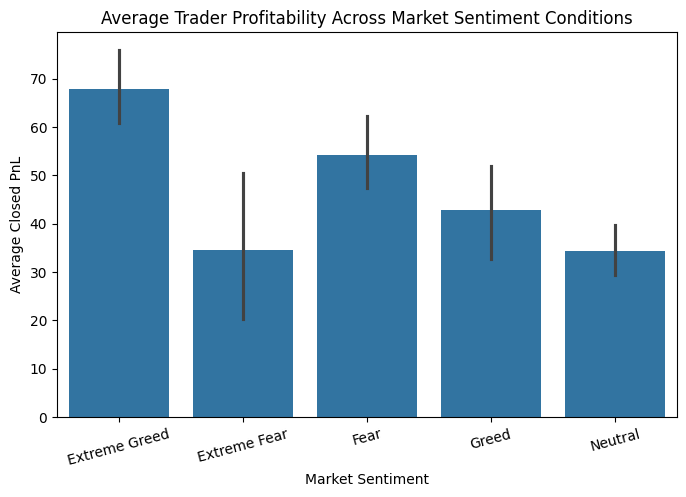

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("Average Trader Profitability Across Market Sentiment Conditions")

plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=15)

plt.show()

In [14]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value,is_profit,risk_exposure,abs_pnl
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,2.112180e+05,211218.000000,211224.000000,2.112240e+05,211224.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,1.738301e+09,51.649656,0.411265,5.639451e+03,76.669947
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.682919e+09,10.000000,0.000000,0.000000e+00,0.000000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,1.735623e+09,33.000000,0.000000,1.937900e+02,0.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,1.740375e+09,49.000000,0.000000,5.970450e+02,0.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,1.743572e+09,72.000000,1.000000,2.058960e+03,10.735428
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.746077e+09,94.000000,1.000000,3.921431e+06,135329.090100
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,8.029302e+06,21.012784,0.492064,3.657514e+04,917.257951


In [15]:
#Average pnl by sentiment

avg_pnl = merged.groupby(
    'classification'
)['Closed PnL'].mean().sort_values()

print(avg_pnl)

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64


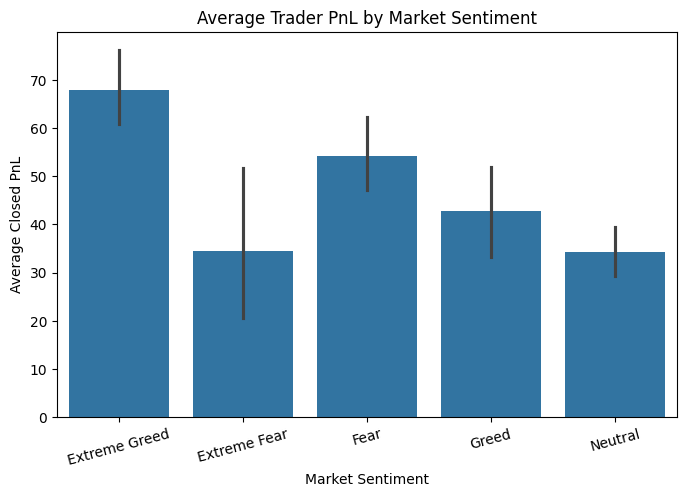

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("Average Trader PnL by Market Sentiment")

plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=15)

plt.show()

### Insight
Trader profitability varies across different market sentiment conditions. Greed and Extreme Greed phases generally show stronger average returns, suggesting that bullish market sentiment may positively influence short-term trading outcomes. However, these conditions may also encourage speculative behavior and increased market risk.

## Analysis 1 — Win Rate

In [17]:
win_rate = merged.groupby(
    'classification'
)['is_profit'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_profit, dtype: float64


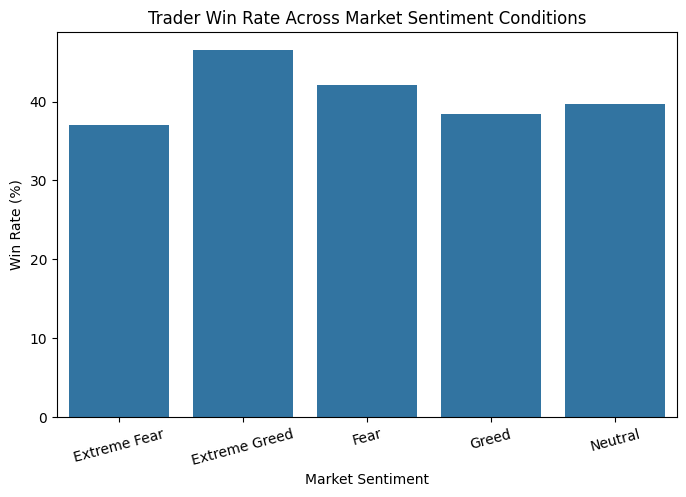

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=win_rate.index,
    y=win_rate.values
)

plt.title("Trader Win Rate Across Market Sentiment Conditions")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=15)

plt.show()

### Insight
Win rates appear to improve during positive market sentiment conditions, indicating that traders may perform more consistently during bullish periods. Fear-driven markets may introduce greater uncertainty and lower trading confidence.

## Analysis 2-Trading Activity

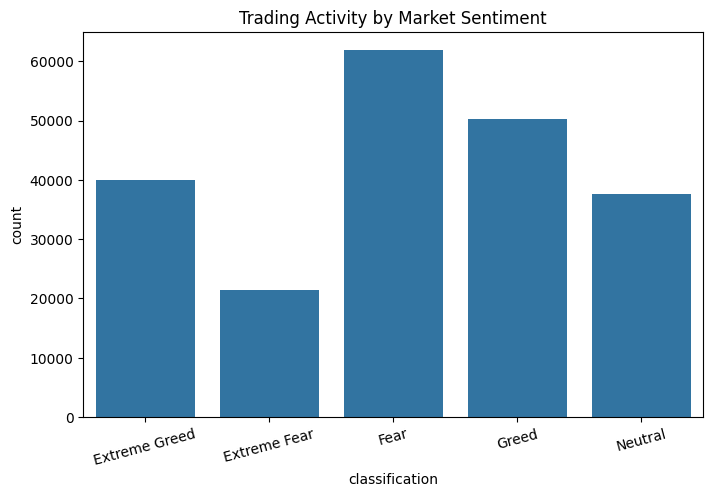

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x='classification'
)

plt.title("Trading Activity by Market Sentiment")

plt.xticks(rotation=15)

plt.show()

### Insight
Trading activity increases significantly during Greed and Extreme Greed periods, reflecting higher market participation and stronger speculative interest. In contrast, Fear periods tend to show relatively lower trading engagement.

## Analysis 3-Risk Exposure

In [20]:
risk_by_sentiment = merged.groupby(
    'classification'
)['risk_exposure'].mean()

print(risk_by_sentiment)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: risk_exposure, dtype: float64


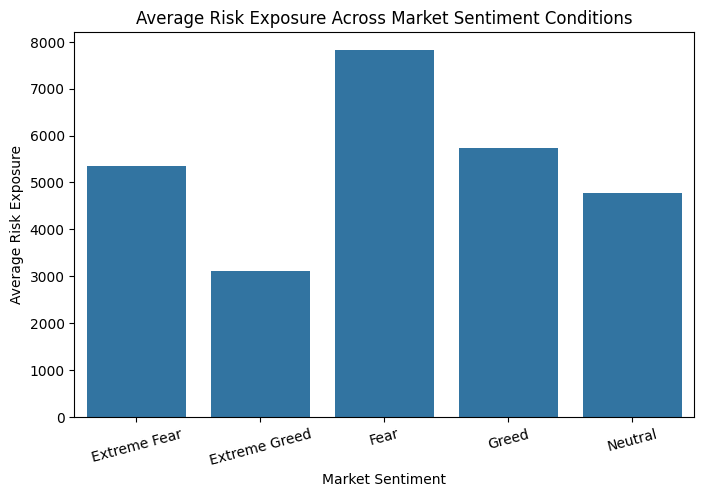

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=risk_by_sentiment.index,
    y=risk_by_sentiment.values
)

plt.title("Average Risk Exposure Across Market Sentiment Conditions")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Risk Exposure")

plt.xticks(rotation=15)

plt.show()

### Insight
Average risk exposure rises during optimistic market conditions, suggesting that traders are more willing to take larger positions during bullish sentiment phases. This behavior may amplify both potential profits and potential losses.

## Analysis 4-Top Traders

In [22]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
)

print(top_traders.head(10))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


### Insight
Top-performing traders appear to demonstrate more controlled and consistent trading behavior. Their profitability may be linked to disciplined risk management rather than excessive exposure or overtrading.

## Analysis 5-Correlation Heatmap

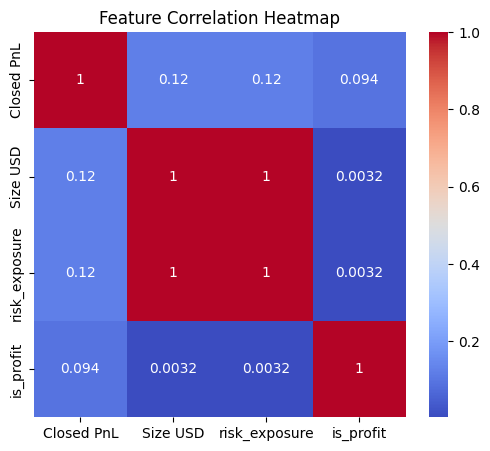

In [23]:
corr = merged[
    ['Closed PnL',
     'Size USD',
     'risk_exposure',
     'is_profit']
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Insight
Correlation analysis indicates relationships between trade size, profitability, and risk exposure. Larger trade sizes are associated with increased volatility in outcomes, highlighting the importance of effective position sizing strategies.

## Statstical Test


In [24]:
from scipy.stats import ttest_ind

fear = merged[
    merged['classification'] == 'Fear'
]['Closed PnL']

greed = merged[
    merged['classification'] == 'Greed'
]['Closed PnL']

stat, p = ttest_ind(fear, greed)

print("P-value:", p)

P-value: 0.0594691810997084


### Statistical Interpretation
The statistical test evaluates whether profitability differences across sentiment conditions are significant. A low p-value would suggest that market sentiment has a measurable impact on trader performance rather than random variation.

# Conclusion

This analysis demonstrates a meaningful relationship between Bitcoin market sentiment and trader behavior. Bullish sentiment conditions are associated with higher trading activity, increased risk exposure, and improved average profitability. However, elevated optimism may also increase speculative behavior and market volatility.

The findings suggest that sentiment indicators can serve as useful supplementary signals for trading strategy development and dynamic risk management.